In [1]:
# =================================================================
# Ensemble Machine Learning for IoMT Network Attack Detection
# Dataset: CICIoMT 2024
# Author: Rahid Parvez
# =================================================================

import os
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'

# --- Path Configuration (Windows and Mac compatible) ---
if os.name == 'nt':
    data_path = r"C:\Users\ICT CELL\Downloads\iomt_paper"
    save_path = r"C:\Users\ICT CELL\iomt-attack-detection"
else:
    data_path = os.path.expanduser("~/Downloads/iomt_paper")
    save_path = os.path.expanduser("~/iomt-attack-detection")

os.makedirs(save_path, exist_ok=True)

# --- Color Map ---
color_map = {
    'DDoS':           '#1565C0',
    'DoS':            '#C62828',
    'Normal':         '#2E7D32',
    'Reconnaissance': '#E65100',
    'ARP':            '#6A1B9A',
    'MQTT':           '#00838F'
}

print("Environment configured successfully.")
print(f"Data path: {data_path}")
print(f"Save path: {save_path}")

Environment configured successfully.
Data path: /Users/rahidparvez/Downloads/iomt_paper
Save path: /Users/rahidparvez/iomt-attack-detection


Training samples  : 7,160,831
Testing samples   : 1,614,182
Total samples     : 8,775,013
Features          : 45
Classes           : 6


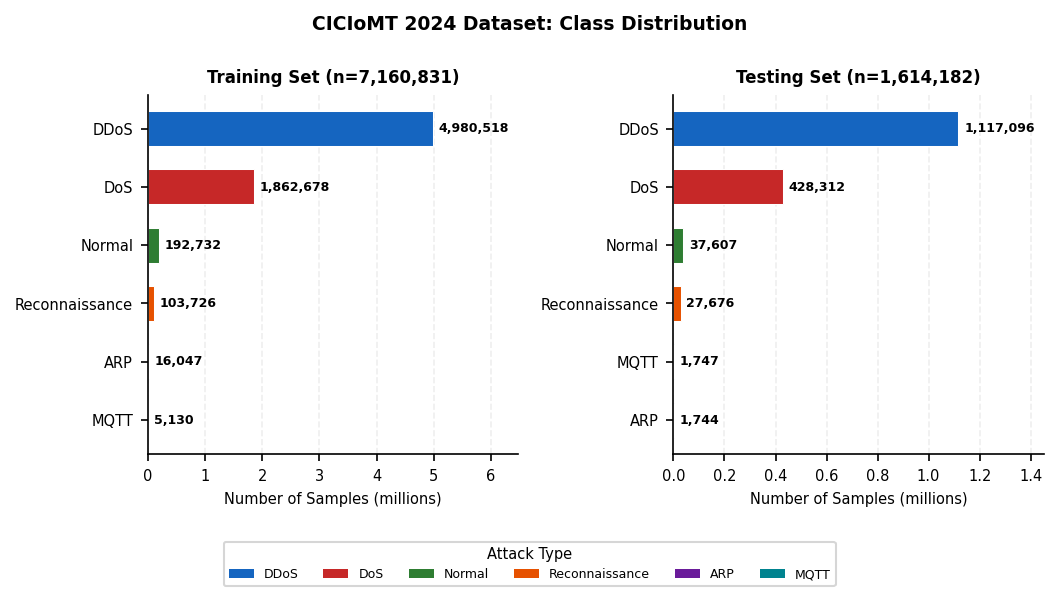

Figure saved: dataset_distribution.png


In [2]:
# =================================================================
# Cell 2: Dataset Loading and Statistical Overview
# =================================================================

df_train = pd.read_parquet(os.path.join(data_path, "training_preprocessed.parquet"))
df_test = pd.read_parquet(os.path.join(data_path, "testing_preprocessed.parquet"))

print(f"Training samples  : {len(df_train):,}")
print(f"Testing samples   : {len(df_test):,}")
print(f"Total samples     : {len(df_train) + len(df_test):,}")
print(f"Features          : {df_train.shape[1] - 1}")
print(f"Classes           : {df_train['label'].nunique()}")

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))
fig.suptitle('CICIoMT 2024 Dataset: Class Distribution',
             fontsize=9, fontweight='bold')

train_counts = df_train['label'].value_counts().sort_values()
test_counts = df_test['label'].value_counts().sort_values()

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Training Set (n=7,160,831)',
                               'Testing Set (n=1,614,182)']):
    bar_colors = [color_map[label] for label in counts.index]
    bars = ax.barh(counts.index, counts.values / 1e6,
                   color=bar_colors, edgecolor='white',
                   linewidth=0.5, height=0.6)
    ax.set_title(title, fontsize=8, fontweight='bold', pad=6)
    ax.set_xlabel('Number of Samples (millions)', fontsize=7)
    ax.grid(axis='x', linestyle='--', alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + max(counts.values / 1e6) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=6, fontweight='bold')
    ax.set_xlim(0, max(counts.values / 1e6) * 1.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[label], label=label)
                   for label in color_map]
fig.legend(handles=legend_elements, title='Attack Type',
           loc='lower center', ncol=6, fontsize=6,
           title_fontsize=7, frameon=True,
           bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'dataset_distribution.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: dataset_distribution.png")

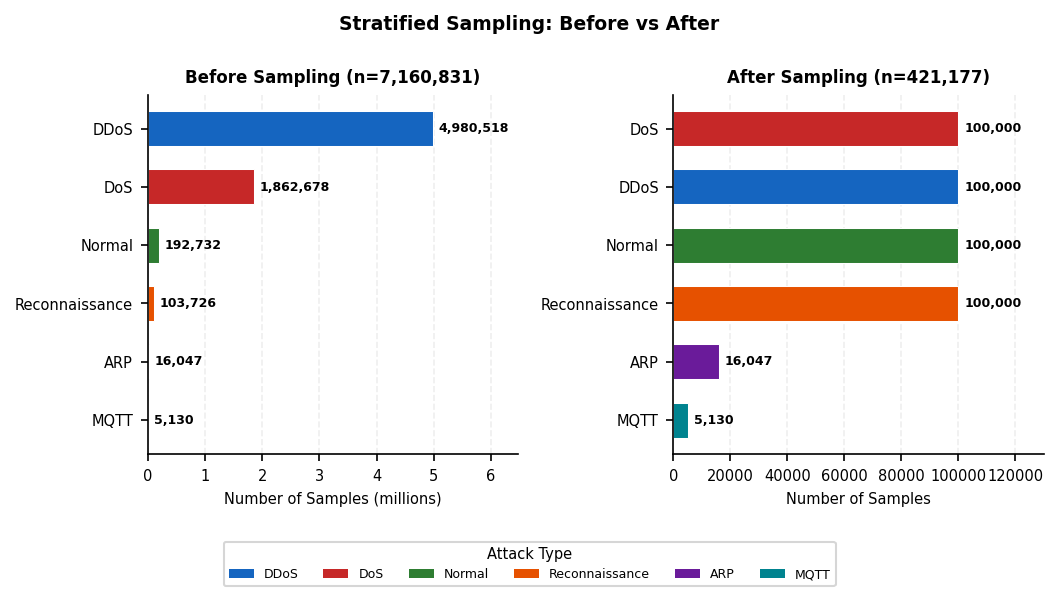

Sampling complete. Total samples: 421,177
Figure saved: sampling_comparison.png


In [3]:
# =================================================================
# Cell 3: Data Preprocessing and Stratified Sampling
# =================================================================

sample_size = 100000 if os.name != 'nt' else 30000

frames = []
for label, group in df_train.groupby('label'):
    n = min(len(group), sample_size)
    frames.append(group.sample(n, random_state=42))

df_sampled = pd.concat(frames).sample(frac=1, random_state=42).reset_index(drop=True)

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))
fig.suptitle('Stratified Sampling: Before vs After',
             fontsize=9, fontweight='bold')

before_counts = df_train['label'].value_counts().sort_values()
after_counts = df_sampled['label'].value_counts().sort_values()

for ax, counts, title in zip(axes,
                              [before_counts, after_counts],
                              ['Before Sampling (n=7,160,831)',
                               f'After Sampling (n={len(df_sampled):,})']):
    bar_colors = [color_map[label] for label in counts.index]
    divisor = 1e6 if counts.max() > 1e5 else 1
    bars = ax.barh(counts.index, counts.values / divisor,
                   color=bar_colors, edgecolor='white',
                   linewidth=0.5, height=0.6)
    ax.set_title(title, fontsize=8, fontweight='bold', pad=6)
    xlabel = 'Number of Samples (millions)' if counts.max() > 1e5 else 'Number of Samples'
    ax.set_xlabel(xlabel, fontsize=7)
    ax.grid(axis='x', linestyle='--', alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + max(counts.values / divisor) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=6, fontweight='bold')
    ax.set_xlim(0, max(counts.values / divisor) * 1.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[label], label=label)
                   for label in color_map]
fig.legend(handles=legend_elements, title='Attack Type',
           loc='lower center', ncol=6, fontsize=6,
           title_fontsize=7, frameon=True,
           bbox_to_anchor=(0.5, -0.12))

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'sampling_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print(f"Sampling complete. Total samples: {len(df_sampled):,}")
print("Figure saved: sampling_comparison.png")

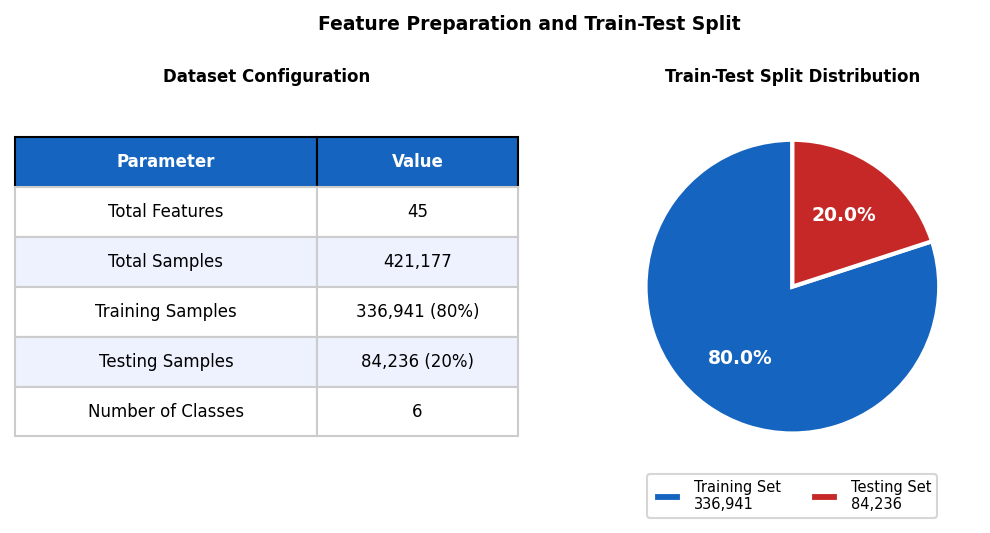

Figure saved: feature_preparation.png


In [4]:
# =================================================================
# Cell 4: Feature Preparation and Train-Test Split
# =================================================================

X = df_sampled.drop('label', axis=1)
y = df_sampled['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))
fig.suptitle('Feature Preparation and Train-Test Split',
             fontsize=9, fontweight='bold')

# Left: Table
axes[0].axis('off')
table_data = [
    ['Total Features', f'{X.shape[1]}'],
    ['Total Samples', f'{len(X):,}'],
    ['Training Samples', f'{len(X_train):,} (80%)'],
    ['Testing Samples', f'{len(X_test):,} (20%)'],
    ['Number of Classes', f'{len(le.classes_)}'],
]

table = axes[0].table(
    cellText=table_data,
    colLabels=['Parameter', 'Value'],
    cellLoc='center',
    loc='center',
    colWidths=[0.6, 0.4]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.2)

for j in range(2):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data) + 1):
    for j in range(2):
        table[i, j].set_facecolor('#EEF2FF' if i % 2 == 0 else '#FFFFFF')
        table[i, j].set_edgecolor('#CCCCCC')

axes[0].set_title('Dataset Configuration', fontsize=8,
                  fontweight='bold', pad=10)

# Right: Pie Chart
split_data = [len(X_train), len(X_test)]
colors_split = ['#1565C0', '#C62828']

wedges, texts, autotexts = axes[1].pie(
    split_data, colors=colors_split, startangle=90,
    autopct='%1.1f%%',
    wedgeprops=dict(edgecolor='white', linewidth=2),
    pctdistance=0.6
)

for text in autotexts:
    text.set_fontsize(9)
    text.set_fontweight('bold')
    text.set_color('white')

axes[1].legend(
    wedges,
    [f'Training Set\n{len(X_train):,}', f'Testing Set\n{len(X_test):,}'],
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    fontsize=7, ncol=2
)

axes[1].set_title('Train-Test Split Distribution',
                  fontsize=8, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'feature_preparation.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: feature_preparation.png")

Analyzing n_estimators for Random Forest...
  n_estimators=  10 : 98.59%
  n_estimators=  25 : 98.72%
  n_estimators=  50 : 98.76%
  n_estimators=  75 : 98.76%
  n_estimators= 100 : 98.76%
  n_estimators= 150 : 98.77%
  n_estimators= 200 : 98.78%

Analyzing max_depth for Decision Tree...
  max_depth=    3 : 89.51%
  max_depth=    5 : 92.35%
  max_depth=   10 : 97.45%
  max_depth=   15 : 98.29%
  max_depth=   20 : 98.44%
  max_depth=   25 : 98.43%
  max_depth= None : 98.35%


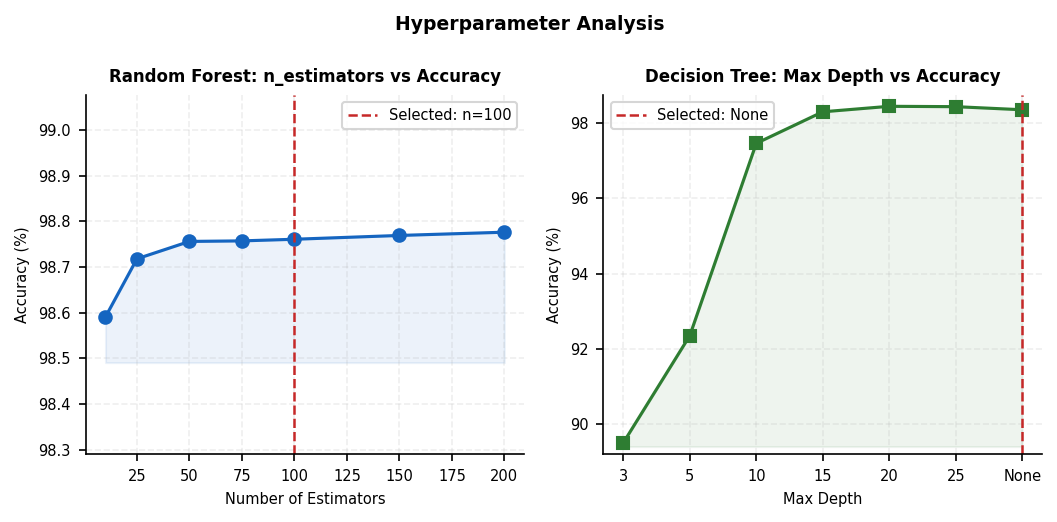

Figure saved: hyperparameter_analysis.png


In [5]:
# =================================================================
# Cell 5: Hyperparameter Analysis
# =================================================================

# --- n_estimators Analysis ---
estimator_range = [10, 25, 50, 75, 100, 150, 200]
rf_scores = []

print("Analyzing n_estimators for Random Forest...")
for n in estimator_range:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    score = accuracy_score(y_test, rf_temp.predict(X_test))
    rf_scores.append(score * 100)
    print(f"  n_estimators={n:>4} : {score*100:.2f}%")

# --- Max Depth Analysis ---
depth_range = [3, 5, 10, 15, 20, 25, None]
dt_scores = []

print("\nAnalyzing max_depth for Decision Tree...")
for d in depth_range:
    dt_temp = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_temp.fit(X_train, y_train)
    score = accuracy_score(y_test, dt_temp.predict(X_test))
    dt_scores.append(score * 100)
    print(f"  max_depth={str(d):>5} : {score*100:.2f}%")

depth_labels = [str(d) if d else 'None' for d in depth_range]

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))
fig.suptitle('Hyperparameter Analysis', fontsize=9, fontweight='bold')

# Left: n_estimators
axes[0].plot(estimator_range, rf_scores,
             marker='o', color='#1565C0', linewidth=1.5, markersize=6)
axes[0].axvline(x=100, color='#C62828', linestyle='--',
                linewidth=1.2, label='Selected: n=100')
axes[0].fill_between(estimator_range, rf_scores,
                      min(rf_scores) - 0.1, alpha=0.08, color='#1565C0')
axes[0].set_xlabel('Number of Estimators', fontsize=7)
axes[0].set_ylabel('Accuracy (%)', fontsize=7)
axes[0].set_title('Random Forest: n_estimators vs Accuracy',
                  fontsize=8, fontweight='bold')
axes[0].legend(fontsize=7)
axes[0].grid(linestyle='--', alpha=0.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(labelsize=7)
axes[0].set_ylim(min(rf_scores) - 0.3, max(rf_scores) + 0.3)

# Right: Max Depth
axes[1].plot(range(len(depth_range)), dt_scores,
             marker='s', color='#2E7D32', linewidth=1.5, markersize=6)
axes[1].axvline(x=depth_labels.index('None'), color='#C62828',
                linestyle='--', linewidth=1.2, label='Selected: None')
axes[1].fill_between(range(len(depth_range)), dt_scores,
                      min(dt_scores) - 0.1, alpha=0.08, color='#2E7D32')
axes[1].set_xticks(range(len(depth_range)))
axes[1].set_xticklabels(depth_labels, fontsize=7)
axes[1].set_xlabel('Max Depth', fontsize=7)
axes[1].set_ylabel('Accuracy (%)', fontsize=7)
axes[1].set_title('Decision Tree: Max Depth vs Accuracy',
                  fontsize=8, fontweight='bold')
axes[1].legend(fontsize=7)
axes[1].grid(linestyle='--', alpha=0.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(labelsize=7)
axes[1].set_ylim(min(dt_scores) - 0.3, max(dt_scores) + 0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'hyperparameter_analysis.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: hyperparameter_analysis.png")

Training individual models...
Decision Tree             Accuracy: 98.35%  Time: 1.97s
Random Forest             Accuracy: 98.76%  Time: 24.36s
Gradient Boosting         Accuracy: 98.35%  Time: 400.14s


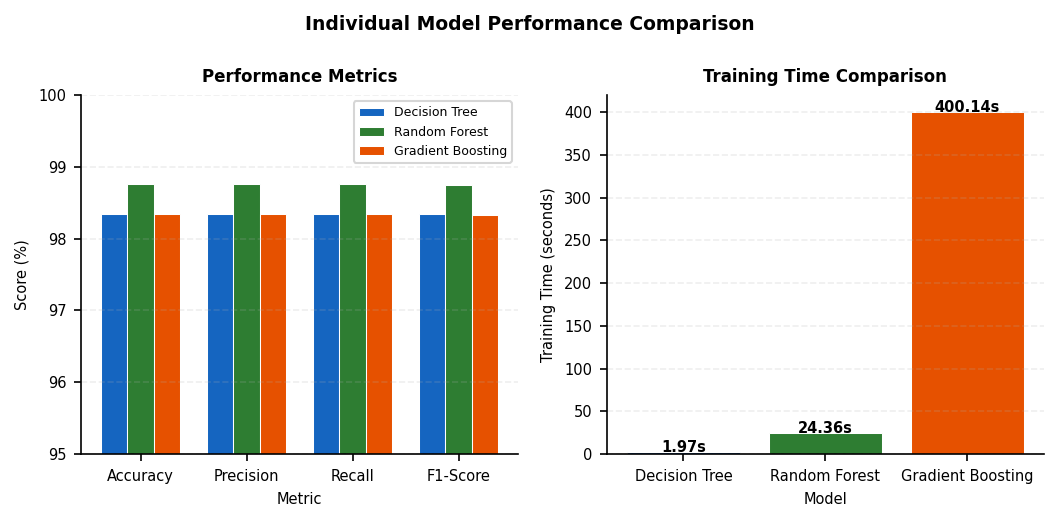

Figure saved: individual_model_comparison.png


In [6]:
# =================================================================
# Cell 6: Individual Model Training and Comparison
# =================================================================

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
print("Training individual models...")
print("=" * 55)

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, output_dict=True)
    results.append({
        'Model': name,
        'Accuracy': acc * 100,
        'Precision': report['weighted avg']['precision'] * 100,
        'Recall': report['weighted avg']['recall'] * 100,
        'F1-Score': report['weighted avg']['f1-score'] * 100,
        'Training Time (s)': round(train_time, 2)
    })
    print(f"{name:<25} Accuracy: {acc*100:.2f}%  Time: {train_time:.2f}s")

print("=" * 55)
results_df = pd.DataFrame(results)

# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))
fig.suptitle('Individual Model Performance Comparison',
             fontsize=9, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = results_df['Model'].tolist()
x = np.arange(len(metrics))
width = 0.25
model_colors = ['#1565C0', '#2E7D32', '#E65100']

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    values = results_df[results_df['Model'] == name][metrics].values[0]
    axes[0].bar(x + i * width, values, width,
                label=name, color=color, edgecolor='white', linewidth=0.5)

axes[0].set_xlabel('Metric', fontsize=7)
axes[0].set_ylabel('Score (%)', fontsize=7)
axes[0].set_title('Performance Metrics', fontsize=8, fontweight='bold')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, fontsize=7)
axes[0].set_ylim(95, 100)
axes[0].legend(fontsize=6)
axes[0].grid(axis='y', linestyle='--', alpha=0.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(labelsize=7)

axes[1].bar(model_names, results_df['Training Time (s)'],
            color=model_colors, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Model', fontsize=7)
axes[1].set_ylabel('Training Time (seconds)', fontsize=7)
axes[1].set_title('Training Time Comparison', fontsize=8, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].tick_params(labelsize=7)

for bar, val in zip(axes[1].patches, results_df['Training Time (s)']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val}s', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'individual_model_comparison.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: individual_model_comparison.png")

In [7]:
# =================================================================
# Cell 7: Ensemble Model Training
# =================================================================

ensemble = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    voting='hard'
)

print("Training Ensemble Model (Voting Classifier)...")
print("Components: Decision Tree + Random Forest + Gradient Boosting")
print("Strategy  : Hard Voting (majority vote)")
print("=" * 55)

start = time.time()
ensemble.fit(X_train, y_train)
ensemble_time = time.time() - start

y_pred = ensemble.predict(X_test)
ensemble_acc = accuracy_score(y_test, y_pred)

print(f"Ensemble Accuracy   : {ensemble_acc*100:.2f}%")
print(f"Training Time       : {ensemble_time:.2f} seconds")
print("=" * 55)

Training Ensemble Model (Voting Classifier)...
Components: Decision Tree + Random Forest + Gradient Boosting
Strategy  : Hard Voting (majority vote)
Ensemble Accuracy   : 98.76%
Training Time       : 769.75 seconds


Ensemble Model Evaluation
Overall Accuracy : 98.76%
                precision    recall  f1-score   support

           ARP       0.92      0.89      0.91      3210
          DDoS       1.00      1.00      1.00     20000
           DoS       1.00      1.00      1.00     20000
          MQTT       0.95      0.88      0.91      1026
        Normal       0.97      0.99      0.98     20000
Reconnaissance       0.99      0.98      0.99     20000

      accuracy                           0.99     84236
     macro avg       0.97      0.96      0.96     84236
  weighted avg       0.99      0.99      0.99     84236



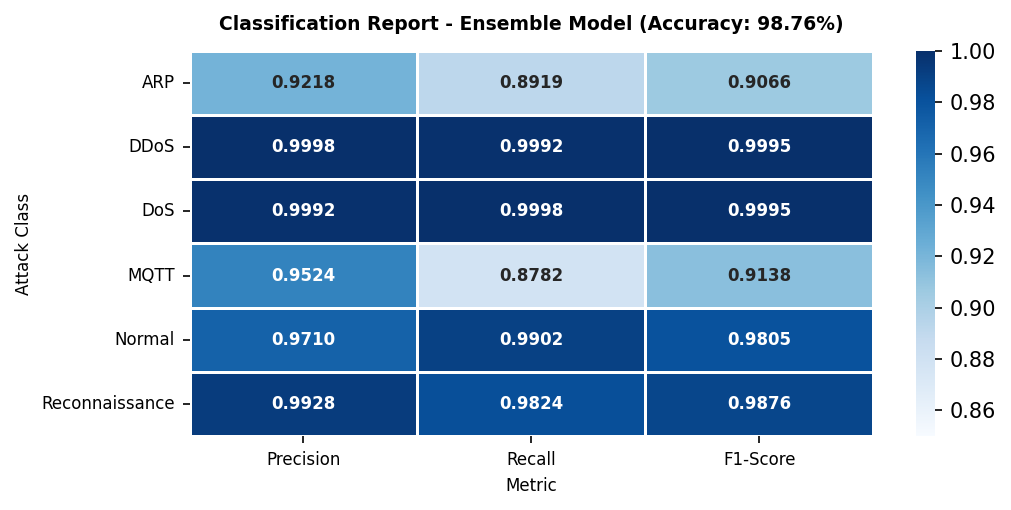

Figure saved: classification_report.png


In [8]:
# =================================================================
# Cell 8: Ensemble Model Evaluation
# =================================================================

y_pred = ensemble.predict(X_test)
ensemble_acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred,
                                target_names=le.classes_,
                                output_dict=True)
report_df = pd.DataFrame(report).transpose().round(4)

print("Ensemble Model Evaluation")
print("=" * 55)
print(f"Overall Accuracy : {ensemble_acc*100:.2f}%")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- Figure ---
fig, ax = plt.subplots(figsize=(7.16, 3.5))

report_plot = report_df.loc[le.classes_, ['precision', 'recall', 'f1-score']]
report_plot.columns = ['Precision', 'Recall', 'F1-Score']

sns.heatmap(report_plot, annot=True, fmt='.4f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            ax=ax, vmin=0.85, vmax=1.0,
            annot_kws={'size': 8, 'weight': 'bold'})

ax.set_title(f'Classification Report - Ensemble Model (Accuracy: {ensemble_acc*100:.2f}%)',
             fontsize=9, fontweight='bold', pad=10)
ax.set_xlabel('Metric', fontsize=8)
ax.set_ylabel('Attack Class', fontsize=8)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'classification_report.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: classification_report.png")

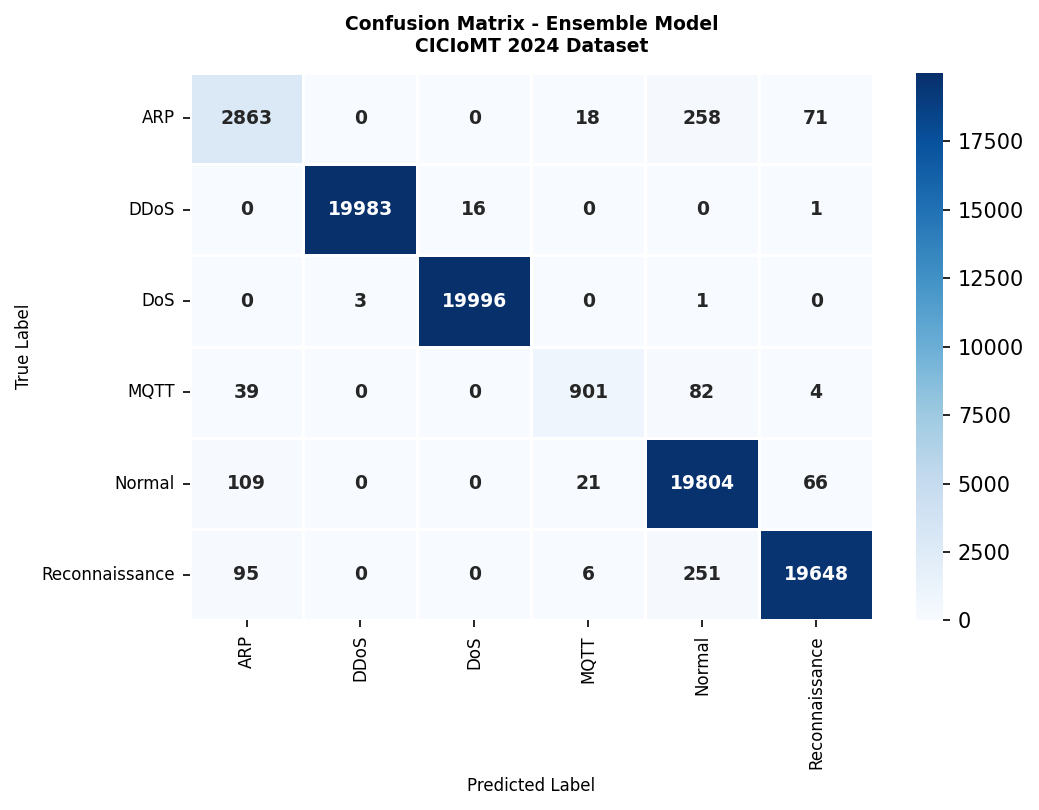

Figure saved: confusion_matrix.png


In [9]:
# =================================================================
# Cell 9: Confusion Matrix
# =================================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7.16, 5.5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9, 'weight': 'bold'},
            ax=ax)

ax.set_title('Confusion Matrix - Ensemble Model\nCICIoMT 2024 Dataset',
             fontsize=9, fontweight='bold', pad=10)
ax.set_xlabel('Predicted Label', fontsize=8)
ax.set_ylabel('True Label', fontsize=8)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'confusion_matrix.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: confusion_matrix.png")

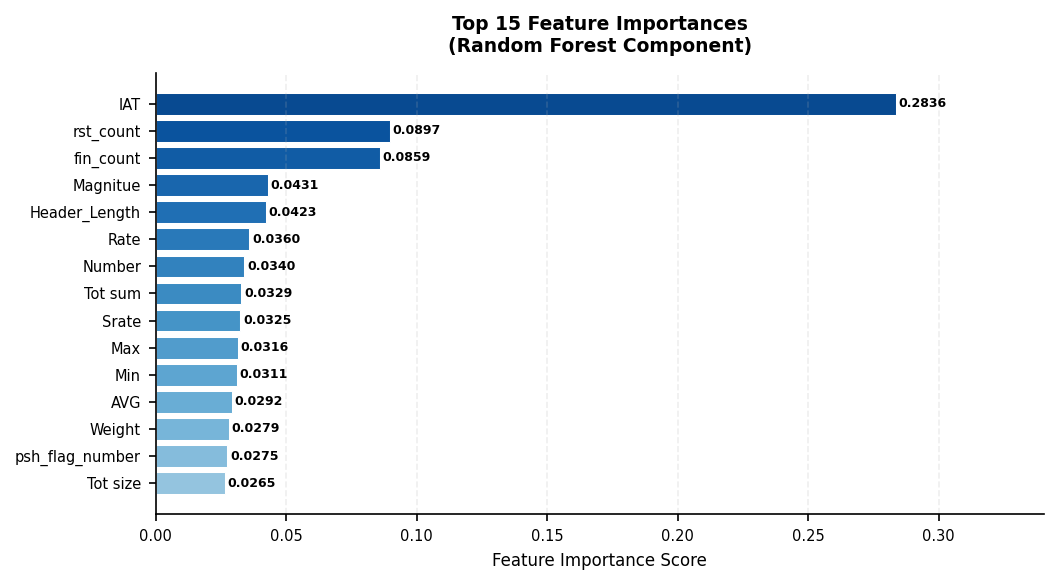

Figure saved: feature_importance.png


In [10]:
# =================================================================
# Cell 10: Feature Importance Analysis
# =================================================================

rf_model = ensemble.estimators_[1]
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1][:15]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

fig, ax = plt.subplots(figsize=(7.16, 4.0))

bars = ax.barh(range(len(top_features)), top_importances[::-1],
               color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top_features))),
               edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features[::-1], fontsize=7)
ax.set_xlabel('Feature Importance Score', fontsize=8)
ax.set_title('Top 15 Feature Importances\n(Random Forest Component)',
             fontsize=9, fontweight='bold', pad=10)
ax.grid(axis='x', linestyle='--', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=7)

for bar, val in zip(bars, top_importances[::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=6, fontweight='bold')

ax.set_xlim(0, max(top_importances) * 1.2)

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'feature_importance.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: feature_importance.png")

5-Fold Cross Validation Results:
Decision Tree             Mean: 98.39%  Std: 0.0418%
Random Forest             Mean: 98.81%  Std: 0.0196%
Gradient Boosting         Mean: 98.34%  Std: 0.0239%
Ensemble (Voting)         Mean: 98.78%  Std: 0.0244%


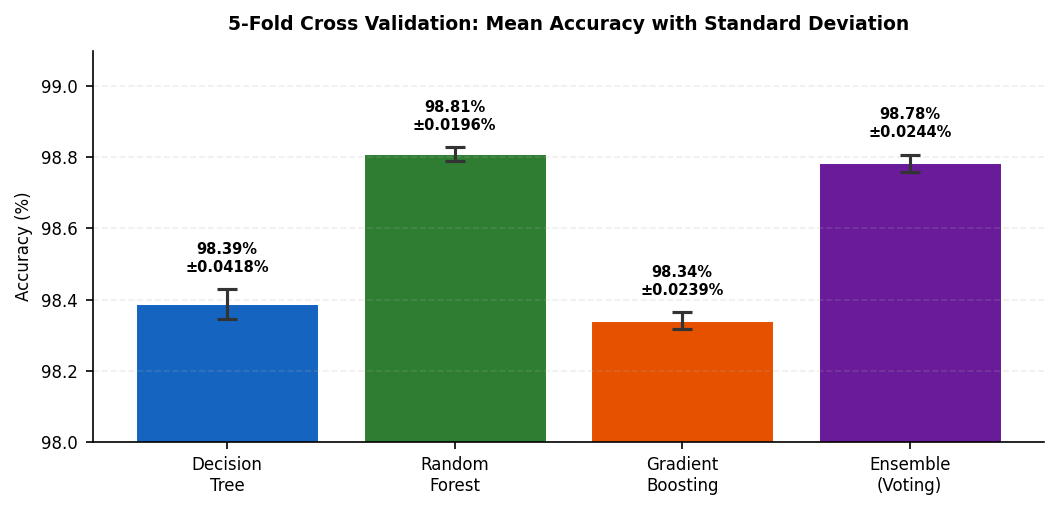

Figure saved: cross_validation.png


In [12]:
# =================================================================
# Cell 11: Cross Validation - Stability Analysis
# =================================================================

from sklearn.model_selection import cross_val_score

cv_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Ensemble (Voting)': VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(random_state=42)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
        ], voting='hard')
}

cv_results = {}
print("5-Fold Cross Validation Results:")
print("=" * 55)

for name, model in cv_models.items():
    scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
    cv_results[name] = scores * 100
    print(f"{name:<25} Mean: {scores.mean()*100:.2f}%  Std: {scores.std()*100:.4f}%")

print("=" * 55)

# --- Figure ---
fig, ax = plt.subplots(figsize=(7.16, 3.5))

model_colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
labels = ['Decision\nTree', 'Random\nForest', 'Gradient\nBoosting', 'Ensemble\n(Voting)']
means = [cv_results[name].mean() for name in cv_models.keys()]
stds = [cv_results[name].std() for name in cv_models.keys()]

bars = ax.bar(labels, means, color=model_colors,
              edgecolor='white', linewidth=0.5,
              yerr=stds, capsize=5,
              error_kw=dict(elinewidth=1.5, ecolor='#333333', capthick=1.5))

ax.set_ylabel('Accuracy (%)', fontsize=8)
ax.set_title('5-Fold Cross Validation: Mean Accuracy with Standard Deviation',
             fontsize=9, fontweight='bold', pad=10)
ax.grid(axis='y', linestyle='--', alpha=0.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8)
ax.set_ylim(98.0, 99.1)

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.05,
            f'{mean:.2f}%\n±{std:.4f}%',
            ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'cross_validation.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved: cross_validation.png")

In [14]:
# =================================================================
# Cell 12: Final Results Summary
# =================================================================

final_results = []

for name, model in models.items():
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    rep = classification_report(y_test, pred, output_dict=True)
    final_results.append({
        'Model': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Precision (%)': round(rep['weighted avg']['precision'] * 100, 2),
        'Recall (%)': round(rep['weighted avg']['recall'] * 100, 2),
        'F1-Score (%)': round(rep['weighted avg']['f1-score'] * 100, 2),
        'CV Mean (%)': round(cv_results[name].mean(), 2),
        'CV Std (%)': round(cv_results[name].std(), 4),
    })

# Ensemble separately
ens_pred = ensemble.predict(X_test)
ens_acc = accuracy_score(y_test, ens_pred)
ens_rep = classification_report(y_test, ens_pred, output_dict=True)
final_results.append({
    'Model': 'Ensemble (Voting)',
    'Accuracy (%)': round(ens_acc * 100, 2),
    'Precision (%)': round(ens_rep['weighted avg']['precision'] * 100, 2),
    'Recall (%)': round(ens_rep['weighted avg']['recall'] * 100, 2),
    'F1-Score (%)': round(ens_rep['weighted avg']['f1-score'] * 100, 2),
    'CV Mean (%)': round(cv_results['Ensemble (Voting)'].mean(), 2),
    'CV Std (%)': round(cv_results['Ensemble (Voting)'].std(), 4),
})

final_df = pd.DataFrame(final_results)

print("TABLE I: Performance Comparison of Classification Models")
print("=" * 85)
print(final_df.to_string(index=False))
print("=" * 85)
print("\nNote: CV = 5-Fold Cross Validation.")

TABLE I: Performance Comparison of Classification Models
            Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  CV Mean (%)  CV Std (%)
    Decision Tree         98.35          98.34       98.35         98.34        98.39      0.0418
    Random Forest         98.76          98.76       98.76         98.75        98.81      0.0196
Gradient Boosting         98.35          98.34       98.35         98.33        98.34      0.0239
Ensemble (Voting)         98.76          98.76       98.76         98.76        98.78      0.0244

Note: CV = 5-Fold Cross Validation.


In [15]:
# =================================================================
# Cell 13: Full Dataset Training - Ensemble Model
# =================================================================

print("Full Dataset Ensemble Training Started...")
print(f"Training samples: {len(df_train):,}")
print("=" * 55)

# --- Full Dataset Preparation ---
X_full = df_train.drop('label', axis=1)
y_full = df_train['label']

le_full = LabelEncoder()
y_full_encoded = le_full.fit_transform(y_full)

X_test_full = df_test.drop('label', axis=1)
y_test_full = le_full.transform(df_test['label'])

# --- Full Ensemble Model ---
ensemble_full = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    voting='hard'
)

start = time.time()
ensemble_full.fit(X_full, y_full_encoded)
train_time = time.time() - start

y_pred_full = ensemble_full.predict(X_test_full)
acc_full = accuracy_score(y_test_full, y_pred_full)

print(f"Training Time  : {train_time/60:.2f} minutes")
print(f"Full Accuracy  : {acc_full*100:.2f}%")
print("=" * 55)
print(classification_report(y_test_full, y_pred_full, 
                             target_names=le_full.classes_))

Full Dataset Ensemble Training Started...
Training samples: 7,160,831
Training Time  : 107.41 minutes
Full Accuracy  : 99.42%
                precision    recall  f1-score   support

           ARP       0.60      0.82      0.69      1744
          DDoS       1.00      0.99      1.00   1117096
           DoS       0.98      1.00      0.99    428312
          MQTT       0.99      0.85      0.92      1747
        Normal       0.97      0.98      0.97     37607
Reconnaissance       0.99      0.98      0.98     27676

      accuracy                           0.99   1614182
     macro avg       0.92      0.94      0.93   1614182
  weighted avg       0.99      0.99      0.99   1614182



In [16]:
# =================================================================
# Cell 14: SMOTE - Handle Class Imbalance for Full Dataset
# =================================================================

from imblearn.over_sampling import SMOTE

print("Applying SMOTE to handle class imbalance...")
print(f"Before SMOTE - Training samples: {len(X_full):,}")
print("Class distribution before SMOTE:")
for label, count in zip(*np.unique(y_full_encoded, return_counts=True)):
    print(f"  {le_full.classes_[label]:<20} {count:>10,}")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_full_smote, y_full_smote = smote.fit_resample(X_full, y_full_encoded)

print(f"\nAfter SMOTE - Training samples: {len(X_full_smote):,}")
print("Class distribution after SMOTE:")
for label, count in zip(*np.unique(y_full_smote, return_counts=True)):
    print(f"  {le_full.classes_[label]:<20} {count:>10,}")

Applying SMOTE to handle class imbalance...
Before SMOTE - Training samples: 7,160,831
Class distribution before SMOTE:
  ARP                      16,047
  DDoS                  4,980,518
  DoS                   1,862,678
  MQTT                      5,130
  Normal                  192,732
  Reconnaissance          103,726

After SMOTE - Training samples: 29,883,108
Class distribution after SMOTE:
  ARP                   4,980,518
  DDoS                  4,980,518
  DoS                   4,980,518
  MQTT                  4,980,518
  Normal                4,980,518
  Reconnaissance        4,980,518


In [17]:
# =================================================================
# Cell 15: Full Ensemble Training on SMOTE Dataset
# =================================================================

print("Training Ensemble on SMOTE dataset...")
print(f"Training samples: {len(X_full_smote):,}")
print("This will take several hours. Please keep MacBook on.")
print("=" * 55)

start = time.time()

ensemble_smote = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    voting='hard'
)

ensemble_smote.fit(X_full_smote, y_full_smote)
train_time = time.time() - start

y_pred_smote = ensemble_smote.predict(X_test_full)
acc_smote = accuracy_score(y_test_full, y_pred_smote)

print(f"Training Time  : {train_time/60:.2f} minutes")
print(f"SMOTE Accuracy : {acc_smote*100:.2f}%")
print("=" * 55)
print(classification_report(y_test_full, y_pred_smote,
                             target_names=le_full.classes_))

Training Ensemble on SMOTE dataset...
Training samples: 29,883,108
This will take several hours. Please keep MacBook on.
Training Time  : 1286.06 minutes
SMOTE Accuracy : 99.34%
                precision    recall  f1-score   support

           ARP       0.48      0.88      0.62      1744
          DDoS       1.00      0.99      1.00   1117096
           DoS       0.98      1.00      0.99    428312
          MQTT       0.95      0.91      0.93      1747
        Normal       0.98      0.95      0.97     37607
Reconnaissance       0.98      0.97      0.97     27676

      accuracy                           0.99   1614182
     macro avg       0.90      0.95      0.91   1614182
  weighted avg       0.99      0.99      0.99   1614182

